In [2]:
import torch
from models.common import *
from models.vae_gaussian import *
from models.vae_flow import *
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from torch.utils.data import DataLoader, TensorDataset
from sklearn.linear_model import RANSACRegressor, LinearRegression

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Load the pretrained models

In [4]:
path_sim = 'logs_gen/GEN_FissionSim1/ckpt_0.000000_39300.pt'
ckpt = torch.load(path_sim, map_location=torch.device(device))
model_sim = GaussianVAE(ckpt['args']).to(device)
model_sim.load_state_dict(ckpt['state_dict'])

<All keys matched successfully>

In [5]:
path_exp = 'logs_gen/GEN_FissionExp1/ckpt_0.000000_41880.pt'
ckpt = torch.load(path_exp, map_location=torch.device(device))
model_exp = GaussianVAE(ckpt['args']).to(device)
model_exp.load_state_dict(ckpt['state_dict'])

<All keys matched successfully>

## Load Datasets for translation

In [6]:
# Load the data
sim_data = np.load('data/Fission/fission_data/Fission_sim.npy')
exp_data = np.load('data/Fission/fission_data/Fission_exp.npy')
# Convert to PyTorch Tensors
sim_data = torch.from_numpy(sim_data).float()
exp_data = torch.from_numpy(exp_data).float()

# Create TensorDatasets
sim_dset = TensorDataset(sim_data)
exp_dset = TensorDataset(exp_data)

exp_loader = DataLoader(
    exp_dset,
    batch_size=10,
    num_workers=0,
)
sim_loader = DataLoader(
    sim_dset,
    batch_size=10,
    num_workers=0,
)

In [7]:
def forward_diffusion(x_0, model):
    """
    Simulates the forward diffusion process in a diffusion model.

    Parameters:
        x_0 (torch.Tensor): The initial input tensor representing the starting point cloud.
        model (object): The diffusion model containing the variance schedule and other parameters.

    Returns:
        list: A list of tensors representing the trajectory of the forward diffusion process. 
              Each tensor corresponds to an intermediate noisy point cloud at a given timestep.
    """
    diffusion = model.diffusion
    num_steps = diffusion.var_sched.num_steps

    trajectory = [x_0]

    for t in range(1, num_steps + 1):
        beta = diffusion.var_sched.betas[t]
        c0 = torch.sqrt(beta).view(-1, 1, 1)       
        c1 = torch.sqrt(1 - beta).view(-1, 1, 1)   
        e_rand = torch.randn_like(x_0)                  
        x_t = c1 * trajectory[-1] + c0 * e_rand         
        trajectory.append(x_t)

    return trajectory

In [8]:
def visualize_point_cloud(point_cloud, sample_index=0):
    """
    Visualize point cloud with charges

    Parameters:
        point_cloud (torch.Tensor): The initial input batch of tensors representing point clouds.
        sample_index: the index of the point cloud to visualize in the batch
    """
    # Extract the sample
    sample = point_cloud[sample_index]

    # Extract x, y, z coordinates
    x = sample[:, 0].numpy()
    y = sample[:, 1].numpy()
    z = sample[:, 2].numpy()
    c = sample[:, 3].numpy()

    # Create a 3D plot
    fig = plt.figure(figsize=(6,4))
    ax = fig.add_subplot(111, projection='3d')

    # Scatter plot
    ax.scatter(x, y, z, c = c, s=2, cmap=plt.cool())

    # Setting labels
    ax.set_xlabel('X axis')
    ax.set_ylabel('Y axis')
    ax.set_zlabel('Z axis')

    # Show the plot
    plt.show()

In [9]:
def forward_diffusion(x_0, model):
    diffusion = model.diffusion
    num_steps = diffusion.var_sched.num_steps

    trajectory = [x_0]

    for t in range(1, num_steps + 1):
        beta = diffusion.var_sched.betas[t]
        c0 = torch.sqrt(beta).view(-1, 1, 1)       
        c1 = torch.sqrt(1 - beta).view(-1, 1, 1)   
        e_rand = torch.randn_like(x_0)                  
        x_t = c1 * trajectory[-1] + c0 * e_rand         
        trajectory.append(x_t)

    return trajectory

In [10]:
def dpm_encoder(x_0, model, context):
    """
    Implementation of the DPM_Encoder.

    This function generates a noisy trajectory of point clouds from an initial point cloud `x_0` and
    then encodes it using a diffusion model by computing the corresponding noise vectors for each
    step in the diffusion process. The function returns the final noisy point cloud and a tensor
    of noise vectors.

    Parameters:
        x_0 (torch.Tensor): The initial input tensor representing the starting point cloud.
        model (object): The diffusion model containing the network and variance schedule.
        context (torch.Tensor): the latent from pointnet encoder of the DPM model.

    Returns:
        tuple: A tuple containing:
            - x_T (torch.Tensor): The final noisy point cloud after the forward diffusion process.
            - eps_tensor (torch.Tensor): A tensor containing the noise vectors for each step in the diffusion process.
    """
    with torch.no_grad():
        batch_size, num_point, dim = x_0.shape
        traj = forward_diffusion(x_0, model)
        diffusion = model.diffusion
        
        epsilon_list = []
        x_T = traj[-1]  # The final noisy point cloud
        for t in range(len(traj)-1, 0, -1):
            
            alpha = diffusion.var_sched.alphas[t]
            alpha_bar = diffusion.var_sched.alpha_bars[t]
            sigma = diffusion.var_sched.get_sigmas(t, flexibility = 0.1)
            
            c0 = 1.0 / torch.sqrt(alpha)
            c1 = (1 - alpha) / torch.sqrt(1 - alpha_bar)
            
            beta = diffusion.var_sched.betas[[t]*batch_size]
            e_theta = diffusion.net(traj[t], beta=beta, context=context)
            mean = c0 * (traj[t] - c1 * e_theta)
            epsilon = (traj[t-1] - mean) / sigma
            epsilon_list.append(epsilon)
        # Convert the list of noise tensors to a single tensor
        eps_tensor = torch.stack(epsilon_list, dim=1)
    return x_T, eps_tensor 

In [11]:
def sample(model, num_points, context, x_T, eps, point_dim=4, flexibility=0.1, ret_traj=False):
        """
        Sample point cloud with the DPM.

        Parameters:
            model (object): The diffusion model containing the network and variance schedule.
            num_points (int): The number of points in the final point cloud.
            context (torch.Tensor): The context tensor for conditioning the model.
            x_T (torch.Tensor): The initial noisy point cloud.
            eps (torch.Tensor): A tensor containing the noise vectors for each step in the reverse diffusion process.
            point_dim (int): The dimensionality of each point in the point cloud (default is 4).
            flexibility (float): The flexibility parameter for adjusting the diffusion schedule (default is 0.1).
            ret_traj (bool): Whether to return the trajectory of intermediate steps (default is False).

        Returns:
            Union[dict, torch.Tensor]: The trajectory of intermediate steps as a dictionary if `ret_traj` is True, 
                                    or the final sampled point cloud as a tensor if `ret_traj` is False.
        """
        batch_size = context.size(0)
        diffusion = model.diffusion
        traj = {diffusion.var_sched.num_steps: x_T}
        for t in range(diffusion.var_sched.num_steps, 0, -1):
            z = eps[:, diffusion.var_sched.num_steps-t] if t > 1 else torch.zeros_like(x_T)
            
            alpha = diffusion.var_sched.alphas[t]
            alpha_bar = diffusion.var_sched.alpha_bars[t]
            sigma = diffusion.var_sched.get_sigmas(t, flexibility)

            c0 = 1.0 / torch.sqrt(alpha)
            c1 = (1 - alpha) / torch.sqrt(1 - alpha_bar)

            x_t = traj[t]
            # print(x_t.shape)
            beta = diffusion.var_sched.betas[[t]*batch_size]
            e_theta = diffusion.net(x_t, beta=beta, context=context)
            x_next = c0 * (x_t - c1 * e_theta) + sigma * z
            # print("NEXT: ", x_next.shape)
            traj[t-1] = x_next.detach()     # Stop gradient and save trajectory.
            traj[t] = traj[t].cpu()         # Move previous output to CPU memory.
            if not ret_traj:
                del traj[t]
        
        if ret_traj:
            return traj
        else:
            return traj[0]

### RANSAC

In [12]:
# =========================
# TRACK EXTRACTION FUNCTIONS
# =========================

def estimate_line_by_z_iter(point_cloud, residual_threshold=5e-2, remove_center_hit=False):
    """
    Estimate a line from a point cloud, parameterized by z:
      x = a_x * z + b_x
      y = a_y * z + b_y
      z = z

    Parameters:
      point_cloud (np.ndarray): Array of shape (n_points, 3) with columns [x, y, z].
      residual_threshold (float): Maximum residual for a data point to be classified as an inlier.
      remove_center_hit (bool): If True, remove points where x^2 + y^2 < 10^2 before fitting.

    Returns:
      median_z (float): The median z–value of the inlier points.
      models (tuple): Tuple containing the two fitted RANSAC regressors (for x and y).
      inliers (np.ndarray): Boolean mask of inliers in the (filtered) point cloud.
    """
    # Use z as independent variable.
    Z = point_cloud[:, 2].reshape(-1, 1)
    
    # Fit x = a_x * z + b_x using RANSAC.
    ransac_x = RANSACRegressor(residual_threshold=residual_threshold)
    ransac_x.fit(Z, point_cloud[:, 0])
    
    # Fit y = a_y * z + b_y using RANSAC.
    ransac_y = RANSACRegressor(residual_threshold=residual_threshold)
    ransac_y.fit(Z, point_cloud[:, 1])
    
    # Combine inlier masks: require a point to be an inlier for both fits.
    inliers = ransac_x.inlier_mask_ & ransac_y.inlier_mask_
    if np.sum(inliers) == 0:
        inliers = np.ones(len(point_cloud), dtype=bool)
    
    # Compute the median z–value among the inlier points.
    median_z = np.median(point_cloud[inliers, 2])
    
    return median_z, (ransac_x, ransac_y), inliers

def find_tracks(point_cloud, n_tracks=3, residual_threshold=50, remove_center_hit=False):
    """
    Iteratively find up to n_tracks tracks (lines) in the point cloud.
    After fitting each track, remove its inlier points before the next fit.

    Parameters:
      point_cloud (np.ndarray): The full point cloud, shape (N,3).
      n_tracks (int): Number of tracks (lines) to find.
      residual_threshold (float): RANSAC residual threshold.

    Returns:
      tracks (list): A list of dictionaries. Each dictionary contains:
                     'median_z': the median z–value of inliers,
                     'models': tuple of fitted RANSAC regressors,
                     'points': the inlier points for that track.
      remaining_points (np.ndarray): Points that were not assigned to any track.
    """
    tracks = []
    # Remove points close to the center if requested.
    if remove_center_hit:
        mask = (point_cloud[:, 0]**2 + point_cloud[:, 1]**2) >= (10**2)
        point_cloud = point_cloud[mask]

    remaining_points = point_cloud.copy()

    for i in range(n_tracks):
        if remaining_points.shape[0] < 10:  # too few points to fit a model
            break
        
        median_z, models, inliers = estimate_line_by_z_iter(remaining_points, residual_threshold)
        track_points = remaining_points[inliers]
        tracks.append({
            'median_z': median_z,
            'models': models,
            'points': track_points
        })
        # Remove inlier points before the next iteration.
        remaining_points = remaining_points[~inliers]
    
    return tracks, remaining_points

def pick_two_lowest_tracks_by_median_z(tracks):
    """
    Given a list of track dictionaries, pick the two that have the smallest
    median z–values among their inlier points.
    
    Returns:
      (trackA, trackB): The two tracks with the lowest median z.
    """
    track_info = [(i, track['median_z']) for i, track in enumerate(tracks)]
    track_info.sort(key=lambda x: x[1])
    idx1, idx2 = track_info[0][0], track_info[1][0]
    return tracks[idx1], tracks[idx2]

def compute_nearest_vertex(track1, track2):
    """
    Compute the vertex (point of closest approach) between two lines.
    
    For each track, define:
       p = [a * median_z + b, a_y * median_z + b_y, median_z]
       d = [a, a_y, 1]  (normalized)
    
    Then, the nearest points c1 and c2 on the two lines are computed as:
       c1 = p1 + ((p2-p1) · n2)/(d1 · n2) * d1,
       c2 = p2 + ((p1-p2) · n1)/(d2 · n1) * d2,
    where:
       n = d1 × d2,
       n2 = d2 × n,   n1 = d1 × n.
    
    The common vertex is defined as (c1 + c2)/2.
    """
    # Extract parameters for track1.
    median_z1 = track1['median_z']
    ransac_x1, ransac_y1 = track1['models']
    a1 = ransac_x1.estimator_.coef_[0]
    b1 = ransac_x1.estimator_.intercept_
    a1y = ransac_y1.estimator_.coef_[0]
    b1y = ransac_y1.estimator_.intercept_
    p1 = np.array([a1 * median_z1 + b1, a1y * median_z1 + b1y, median_z1])
    d1 = np.array([a1, a1y, 1.0])
    d1 /= np.linalg.norm(d1)
    
    # Extract parameters for track2.
    median_z2 = track2['median_z']
    ransac_x2, ransac_y2 = track2['models']
    a2 = ransac_x2.estimator_.coef_[0]
    b2 = ransac_x2.estimator_.intercept_
    a2y = ransac_y2.estimator_.coef_[0]
    b2y = ransac_y2.estimator_.intercept_
    p2 = np.array([a2 * median_z2 + b2, a2y * median_z2 + b2y, median_z2])
    d2 = np.array([a2, a2y, 1.0])
    d2 /= np.linalg.norm(d2)
    
    n = np.cross(d1, d2)
    if np.linalg.norm(n) < 1e-8:
        return 0.5 * (p1 + p2)
    n2 = np.cross(d2, n)
    c1 = p1 + (np.dot((p2 - p1), n2) / np.dot(d1, n2)) * d1
    n1 = np.cross(d1, n)
    c2 = p2 + (np.dot((p1 - p2), n1) / np.dot(d2, n1)) * d2
    return 0.5 * (c1 + c2)

In [13]:
# =========================
# VISUALIZATION FUNCTION FOR TWO EVENTS
# =========================

def visualize_two_events_tracks_2d_samecolor(tracks1, vertex1, remaining1, 
                                     tracks2, vertex2, remaining2, z_range=100):
    """
    Visualize the tracks from two events in two 2D subplots (x vs. z and y vs. z).
    All tracks for event 1 will be drawn in red (solid lines) and all tracks for event 2 in blue (dashed lines).
    Also mark the computed common vertex for each event.

    Parameters:
      tracks1 (list): Tracks (list of dicts) for event 1.
      vertex1 (np.ndarray): Computed common vertex for event 1 (from two selected tracks).
      remaining1 (np.ndarray): Unassigned points for event 1.
      tracks2 (list): Tracks for event 2.
      vertex2 (np.ndarray): Computed common vertex for event 2.
      remaining2 (np.ndarray): Unassigned points for event 2.
      z_range (float): Half-range around a track's median z to plot the fitted line.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    ax_xz, ax_yz = axes

    # Set constant colors for each event.
    event1_color = 'red'
    event2_color = 'blue'
    
    # Plot Event 1 tracks.
    for idx, track in enumerate(tracks1):
        median_z = track['median_z']
        ransac_x, ransac_y = track['models']
        z_vals = np.linspace(median_z - z_range, median_z + z_range, 100)
        x_vals = ransac_x.estimator_.coef_[0] * z_vals + ransac_x.estimator_.intercept_
        y_vals = ransac_y.estimator_.coef_[0] * z_vals + ransac_y.estimator_.intercept_
        
        x = track['points'][:, 0]
        y = track['points'][:, 1]
        z = track['points'][:, 2]

        ax_xz.plot(z_vals, x_vals, color=event1_color, lw=2,
                   label='Event1 Tracks' if idx==0 else None)
        ax_xz.scatter(z, x,
                      color=event1_color, alpha=0.5, s=20)
        ax_yz.plot(z_vals, y_vals, color=event1_color, lw=2,
                   label='Event1 Tracks' if idx==0 else None)
        ax_yz.scatter(z, y,
                      color=event1_color, alpha=0.5, s=20)
    
    # Plot unassigned points for Event 1.
    if remaining1 is not None and remaining1.shape[0] > 0:
        ax_xz.scatter(remaining1[:, 2], remaining1[:, 0],
                      color='gray', alpha=0.3, s=10, label='Event1 Unassigned')
        ax_yz.scatter(remaining1[:, 2], remaining1[:, 1],
                      color='gray', alpha=0.3, s=10, label='Event1 Unassigned')
    
    # Plot Event 2 tracks.
    for idx, track in enumerate(tracks2):
        median_z = track['median_z']
        ransac_x, ransac_y = track['models']
        z_vals = np.linspace(median_z - z_range, median_z + z_range, 100)
        x_vals = ransac_x.estimator_.coef_[0] * z_vals + ransac_x.estimator_.intercept_
        y_vals = ransac_y.estimator_.coef_[0] * z_vals + ransac_y.estimator_.intercept_

        x = track['points'][:, 0]
        y = track['points'][:, 1]
        z = track['points'][:, 2]
        
        ax_xz.plot(z_vals, x_vals, color=event2_color, lw=2, linestyle='--',
                   label='Event2 Tracks' if idx==0 else None)
        ax_xz.scatter(z, x,
                      color=event2_color, alpha=0.5, s=20)
        ax_yz.plot(z_vals, y_vals, color=event2_color, lw=2, linestyle='--',
                   label='Event2 Tracks' if idx==0 else None)
        ax_yz.scatter(z, y,
                      color=event2_color, alpha=0.5, s=20)
    
    # Plot unassigned points for Event 2.
    if remaining2 is not None and remaining2.shape[0] > 0:
        ax_xz.scatter(remaining2[:, 2], remaining2[:, 0],
                      color='lightgray', alpha=0.3, s=10, label='Event2 Unassigned')
        ax_yz.scatter(remaining2[:, 2], remaining2[:, 1],
                      color='lightgray', alpha=0.3, s=10, label='Event2 Unassigned')
    
    # Mark the computed common vertices.
    ax_xz.scatter(vertex1[2], vertex1[0], color='black', s=150,
                  marker='D', label='Event1 Common Vertex')
    ax_yz.scatter(vertex1[2], vertex1[1], color='black', s=150,
                  marker='D', label='Event1 Common Vertex')
    ax_xz.scatter(vertex2[2], vertex2[0], color='black', s=150,
                  marker='o', label='Event2 Common Vertex')
    ax_yz.scatter(vertex2[2], vertex2[1], color='black', s=150,
                  marker='o', label='Event2 Common Vertex')
    
    ax_xz.set_xlabel('Z')
    ax_xz.set_ylabel('X')
    ax_xz.set_title('X vs Z')
    ax_xz.legend(loc='best', fontsize='small')
    
    ax_yz.set_xlabel('Z')
    ax_yz.set_ylabel('Y')
    ax_yz.set_title('Y vs Z')
    ax_yz.legend(loc='best', fontsize='small')
    
    plt.suptitle("Visualization of Two Events: Event1 in Red, Event2 in Blue")
    plt.show()

In [14]:
# =========================
# VISUALIZATION FUNCTION FOR TWO EVENTS
# =========================

def visualize_two_events_tracks_2d(tracks1, vertex1, remaining1, 
                                     tracks2, vertex2, remaining2, z_range=100):
    """
    Visualize the tracks from two events in two 2D subplots (x vs. z and y vs. z).
    Draw all tracks for each event, using different line styles/colors to distinguish
    between event1 and event2. Also mark the computed common vertex for each event.

    Parameters:
      tracks1 (list): Tracks (list of dicts) for event 1.
      vertex1 (np.ndarray): Computed common vertex for event 1 (from two selected tracks).
      remaining1 (np.ndarray): Unassigned points for event 1.
      tracks2 (list): Tracks for event 2.
      vertex2 (np.ndarray): Computed common vertex for event 2.
      remaining2 (np.ndarray): Unassigned points for event 2.
      z_range (float): Half-range around a track's median z to plot the fitted line.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    ax_xz, ax_yz = axes

    # Colors for event 1 tracks.
    colors1 = ['magenta', 'green', 'blue']
    # Colors (dashed) for event 2 tracks.
    colors2 = ['orange', 'cyan', 'purple']
    
    # Plot Event 1 tracks.
    for idx, track in enumerate(tracks1):
        median_z = track['median_z']
        ransac_x, ransac_y = track['models']
        z_vals = np.linspace(median_z - z_range, median_z + z_range, 100)
        x_vals = ransac_x.estimator_.coef_[0] * z_vals + ransac_x.estimator_.intercept_
        y_vals = ransac_y.estimator_.coef_[0] * z_vals + ransac_y.estimator_.intercept_
        ax_xz.plot(z_vals, x_vals, color=colors1[idx % len(colors1)], lw=2,
                   label=f'Event1 Track {idx+1}')
        ax_xz.scatter(track['points'][:, 2], track['points'][:, 0],
                      color=colors1[idx % len(colors1)], alpha=0.5, s=20)
        ax_yz.plot(z_vals, y_vals, color=colors1[idx % len(colors1)], lw=2,
                   label=f'Event1 Track {idx+1}')
        ax_yz.scatter(track['points'][:, 2], track['points'][:, 1],
                      color=colors1[idx % len(colors1)], alpha=0.5, s=20)
    
    # Plot unassigned points for event 1.
    if remaining1 is not None and remaining1.shape[0] > 0:
        ax_xz.scatter(remaining1[:, 2], remaining1[:, 0],
                      color='gray', alpha=0.3, s=10, label='Event1 Unassigned')
        ax_yz.scatter(remaining1[:, 2], remaining1[:, 1],
                      color='gray', alpha=0.3, s=10, label='Event1 Unassigned')
    
    # Plot Event 2 tracks.
    for idx, track in enumerate(tracks2):
        median_z = track['median_z']
        ransac_x, ransac_y = track['models']
        z_vals = np.linspace(median_z - z_range, median_z + z_range, 100)
        x_vals = ransac_x.estimator_.coef_[0] * z_vals + ransac_x.estimator_.intercept_
        y_vals = ransac_y.estimator_.coef_[0] * z_vals + ransac_y.estimator_.intercept_
        ax_xz.plot(z_vals, x_vals, color=colors2[idx % len(colors2)], lw=2,
                   linestyle='--', label=f'Event2 Track {idx+1}')
        ax_xz.scatter(track['points'][:, 2], track['points'][:, 0],
                      color=colors2[idx % len(colors2)], alpha=0.5, s=20)
        ax_yz.plot(z_vals, y_vals, color=colors2[idx % len(colors2)], lw=2,
                   linestyle='--', label=f'Event2 Track {idx+1}')
        ax_yz.scatter(track['points'][:, 2], track['points'][:, 1],
                      color=colors2[idx % len(colors2)], alpha=0.5, s=20)
    
    # Plot unassigned points for event 2.
    if remaining2 is not None and remaining2.shape[0] > 0:
        ax_xz.scatter(remaining2[:, 2], remaining2[:, 0],
                      color='lightgray', alpha=0.3, s=10, label='Event2 Unassigned')
        ax_yz.scatter(remaining2[:, 2], remaining2[:, 1],
                      color='lightgray', alpha=0.3, s=10, label='Event2 Unassigned')
    
    # Mark the computed common vertices.
    ax_xz.scatter(vertex1[2], vertex1[0], color='black', s=150, marker='D',
                  label='Event1 Common Vertex')
    ax_yz.scatter(vertex1[2], vertex1[1], color='black', s=150, marker='D',
                  label='Event1 Common Vertex')
    ax_xz.scatter(vertex2[2], vertex2[0], color='red', s=150, marker='D',
                  label='Event2 Common Vertex')
    ax_yz.scatter(vertex2[2], vertex2[1], color='red', s=150, marker='D',
                  label='Event2 Common Vertex')
    
    ax_xz.set_xlabel('Z')
    ax_xz.set_ylabel('X')
    ax_xz.set_title('X vs Z')
    ax_xz.legend(loc='best', fontsize='small')
    
    ax_yz.set_xlabel('Z')
    ax_yz.set_ylabel('Y')
    ax_yz.set_title('Y vs Z')
    ax_yz.legend(loc='best', fontsize='small')
    
    plt.suptitle("Visualization of Two Events: Tracks and Common Vertices")
    plt.show()

Successfully encoded


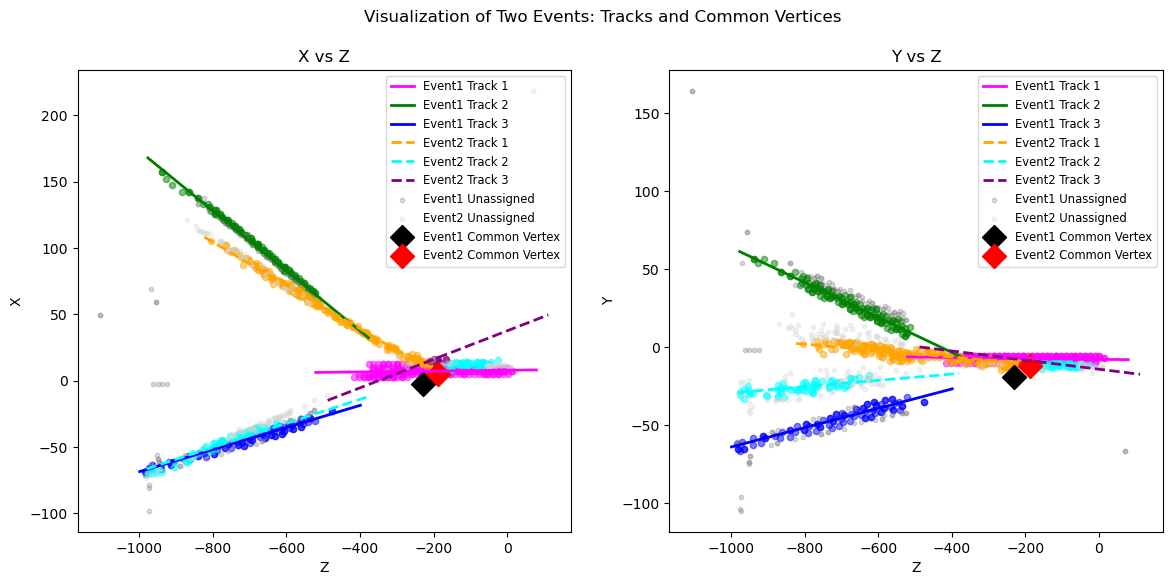

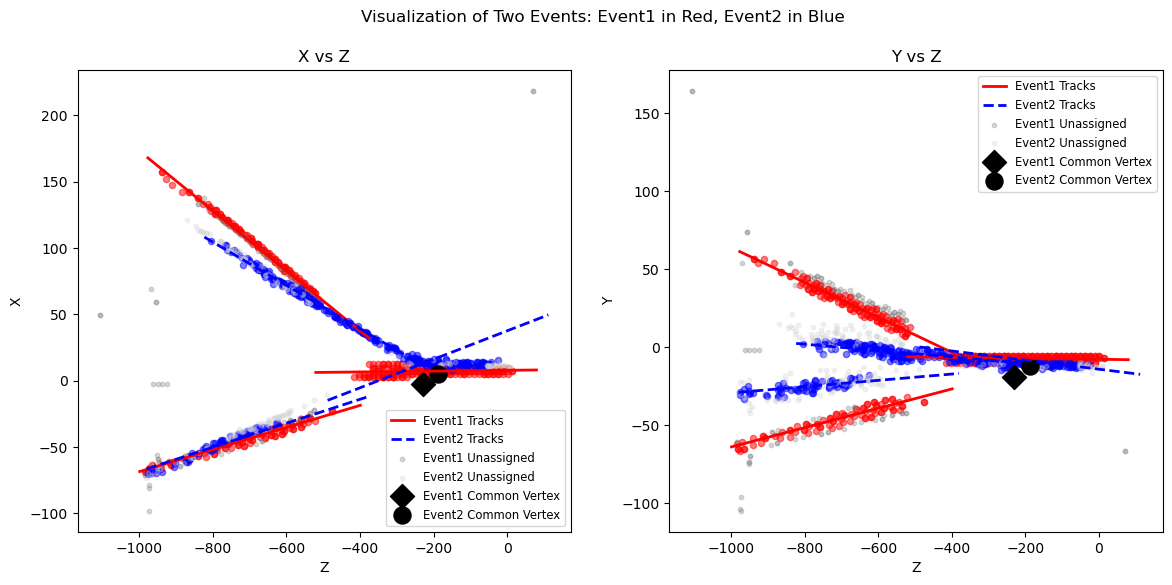

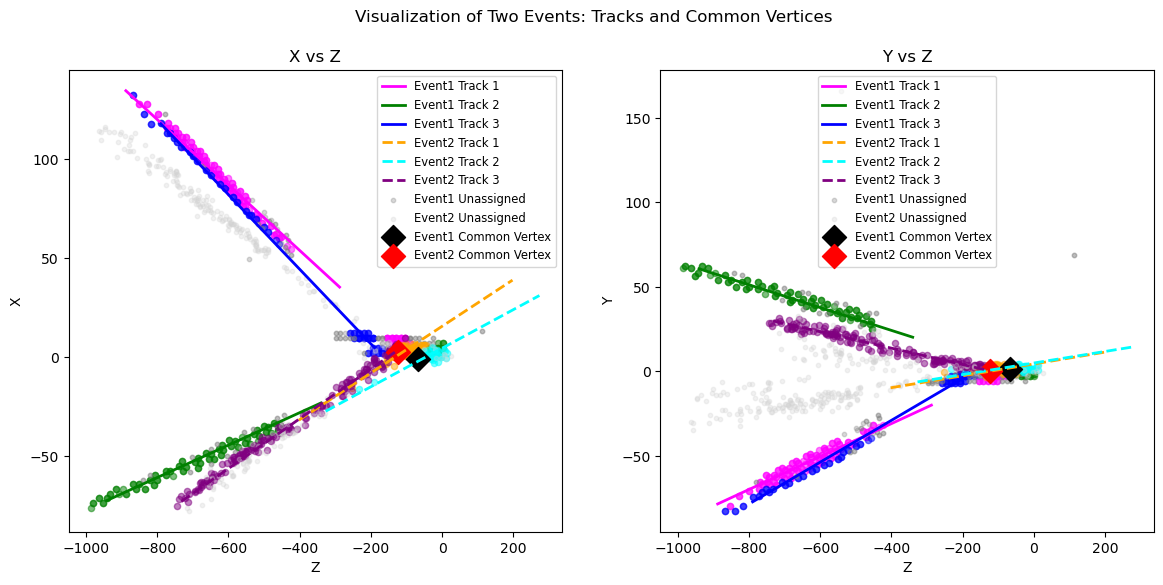

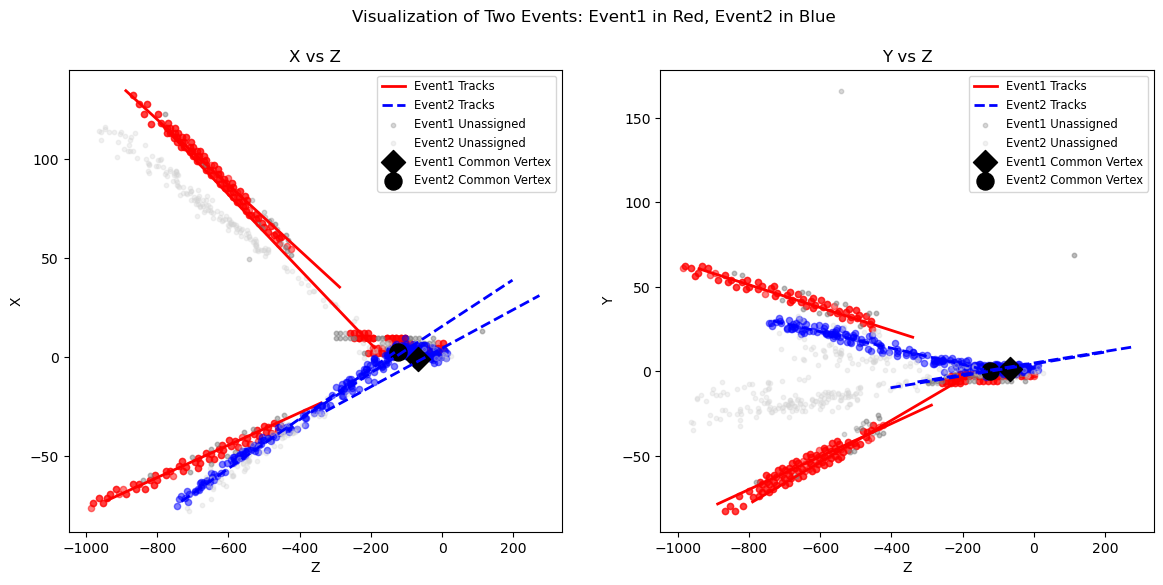

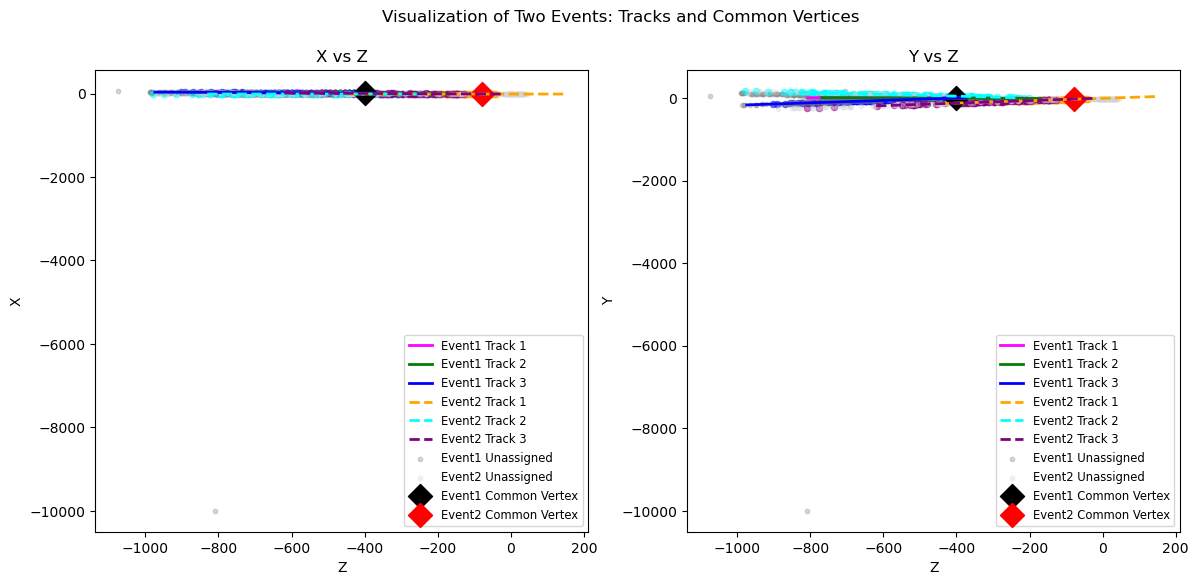

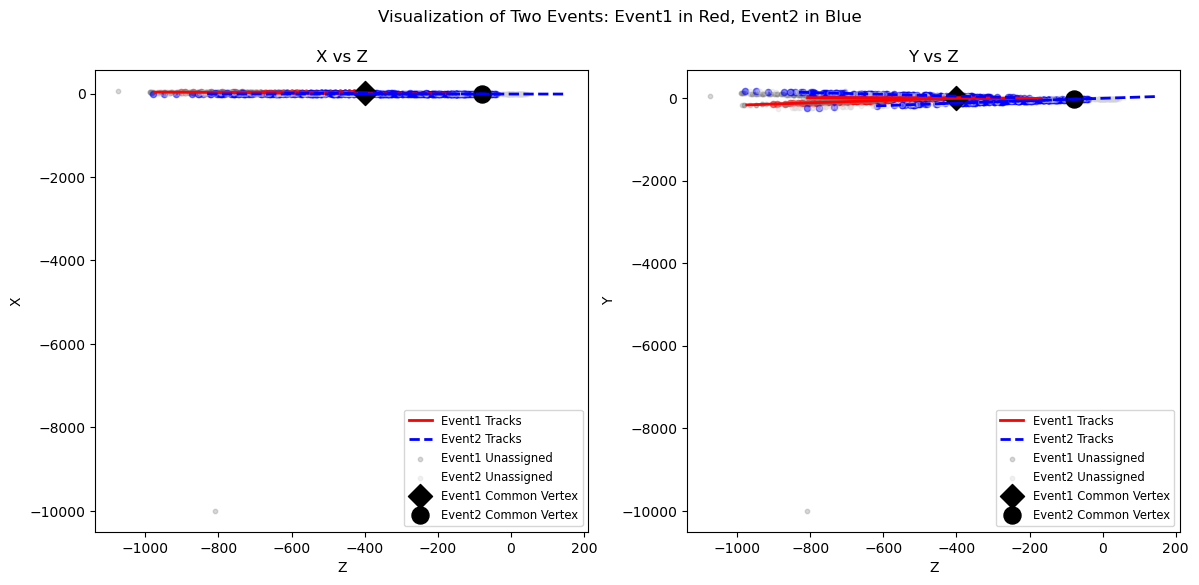

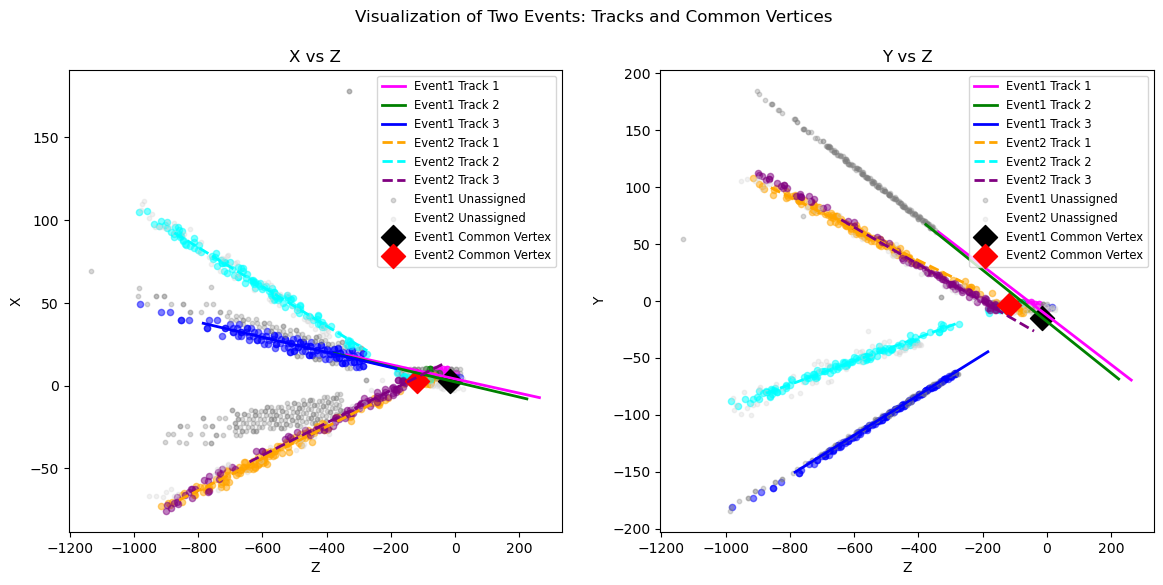

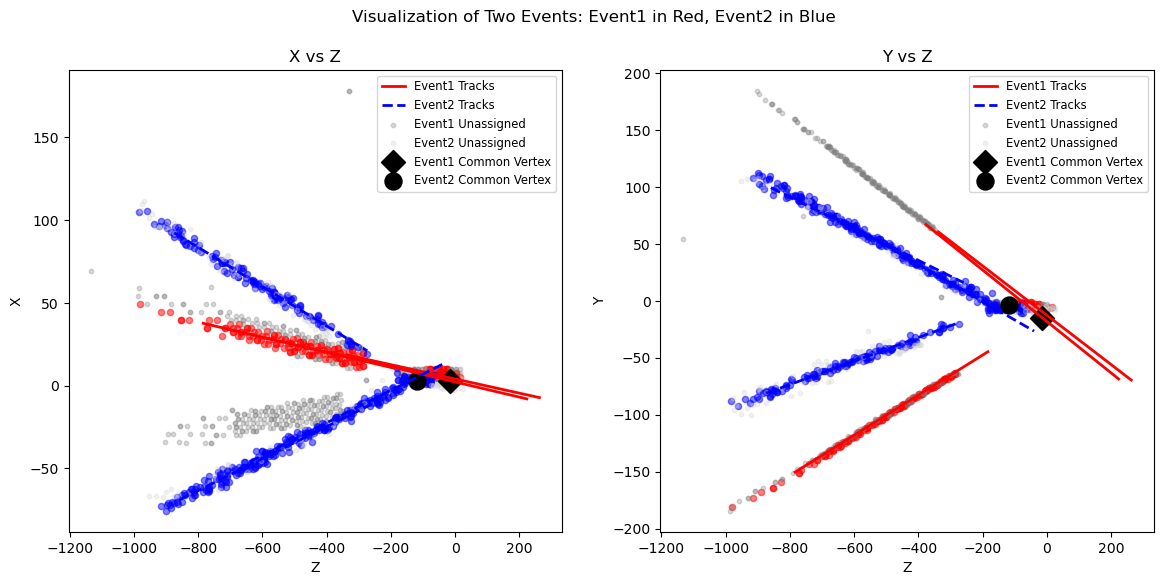

Not enough tracks found in event 1 to compute a vertex.


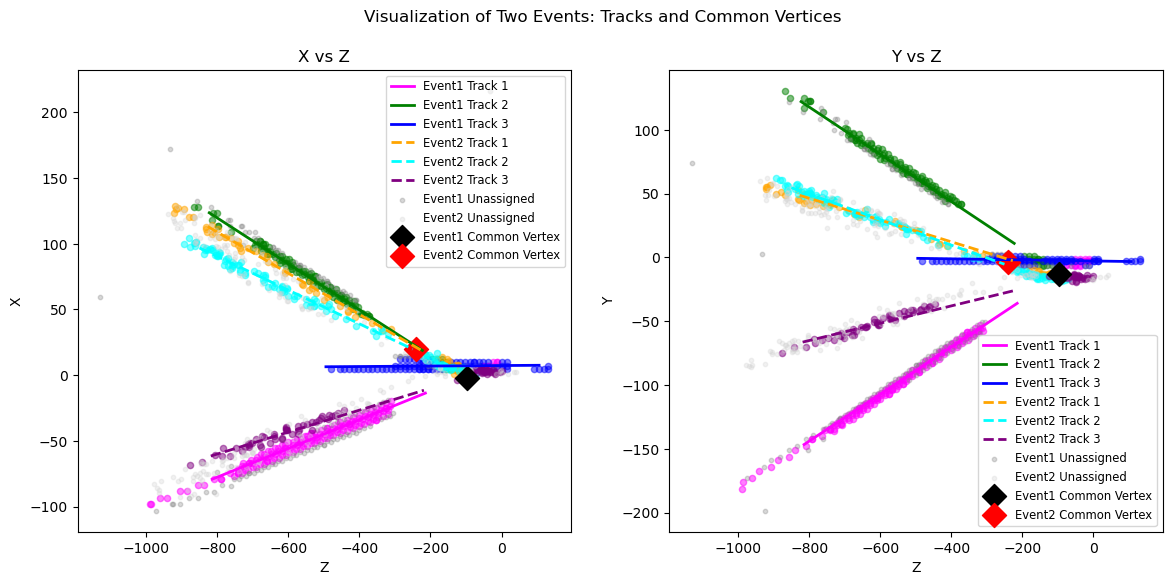

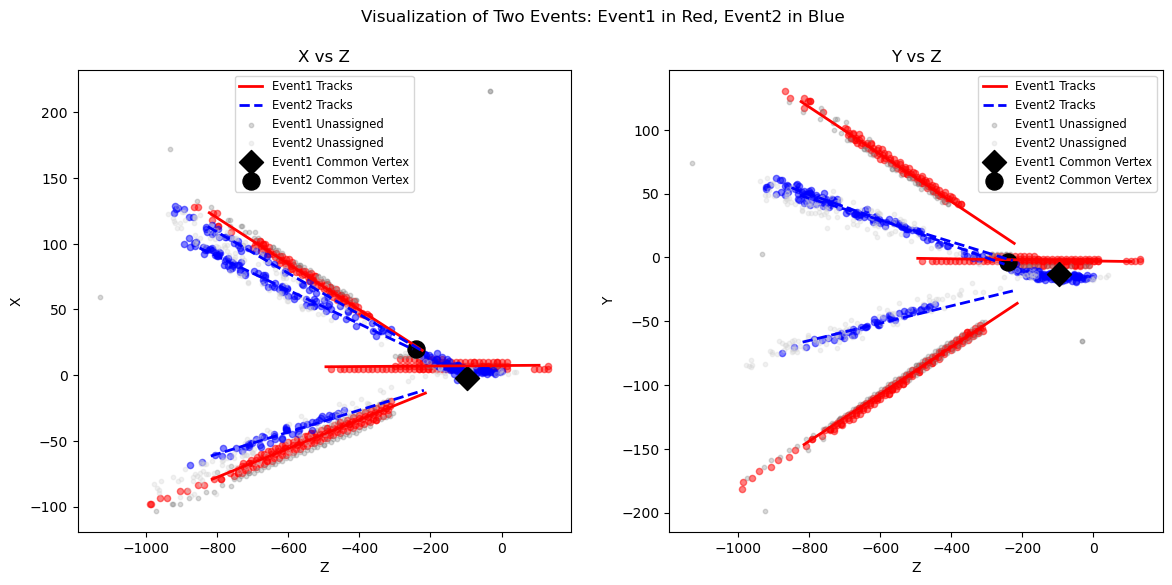

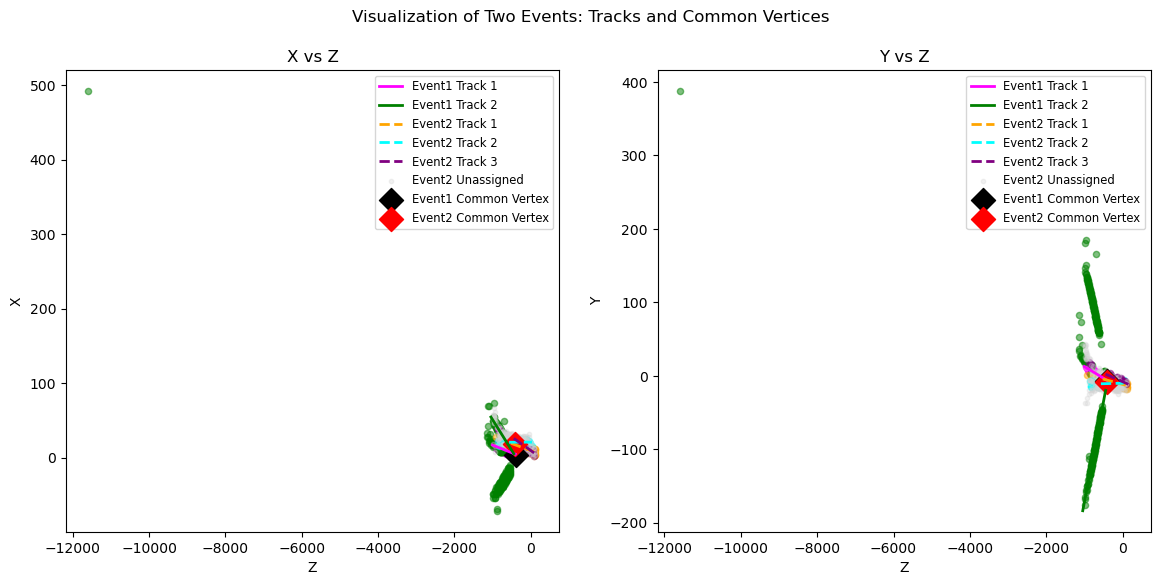

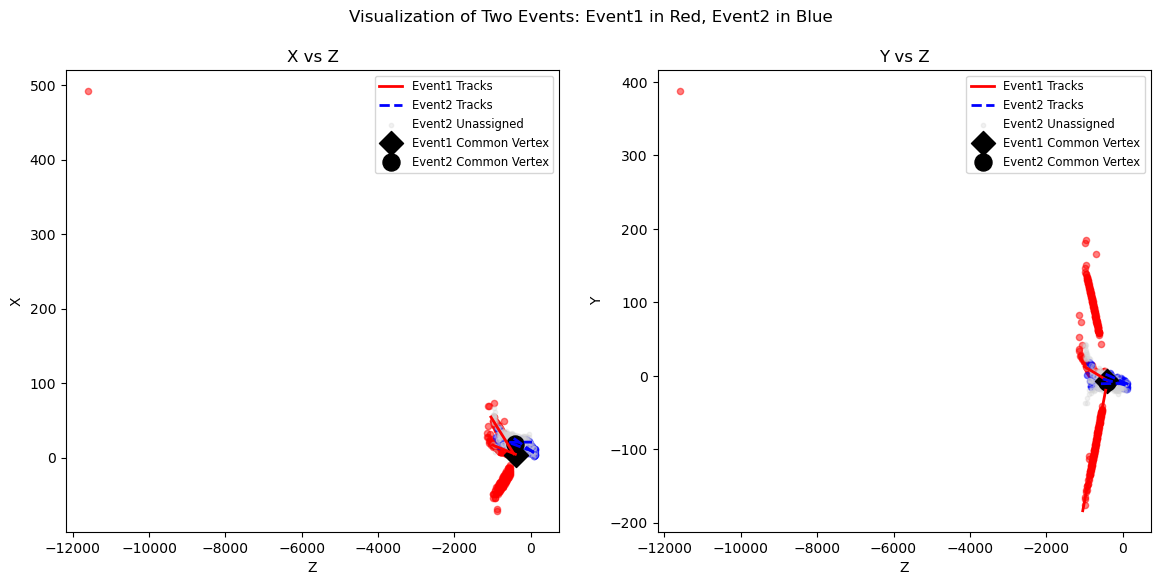

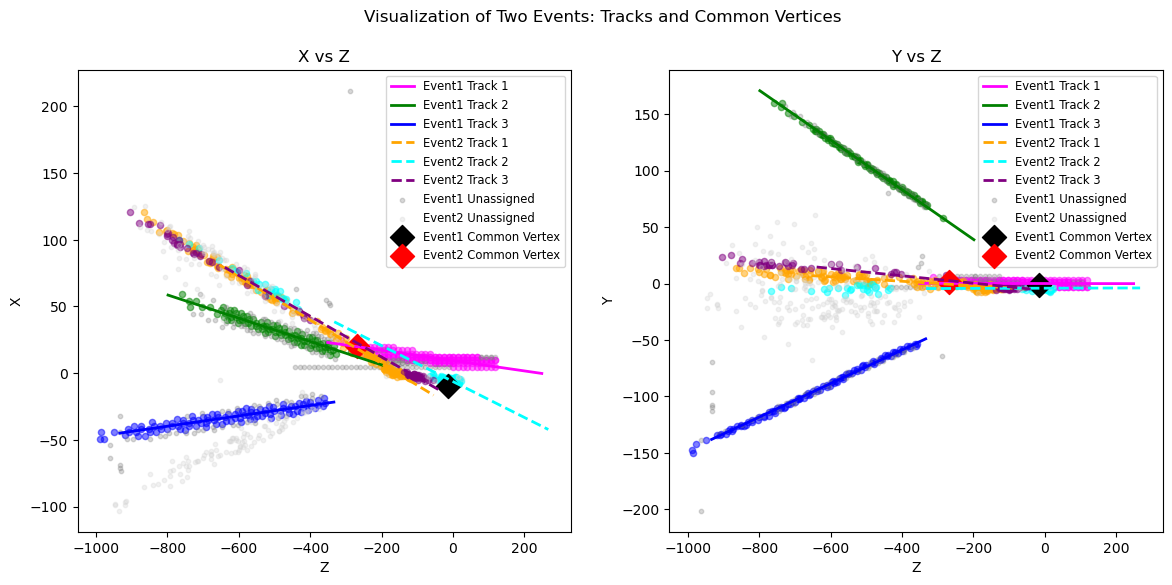

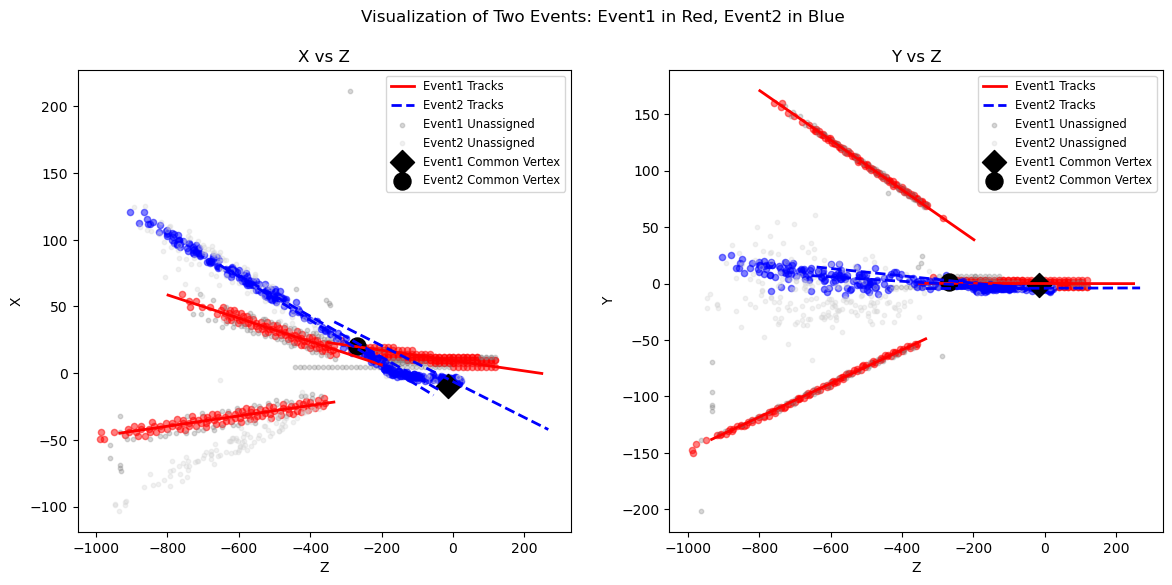

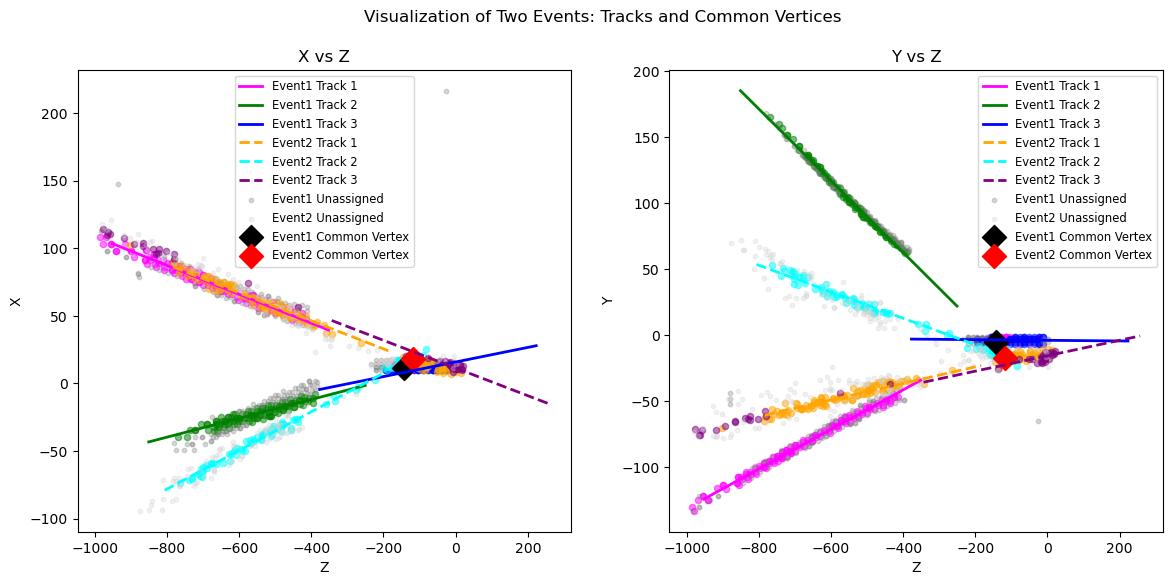

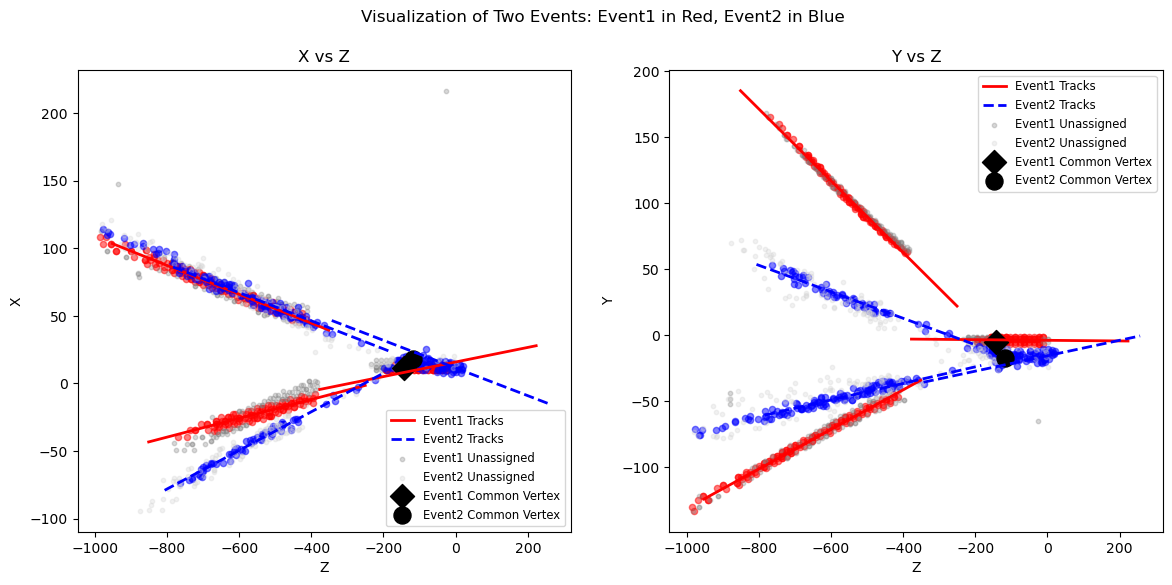

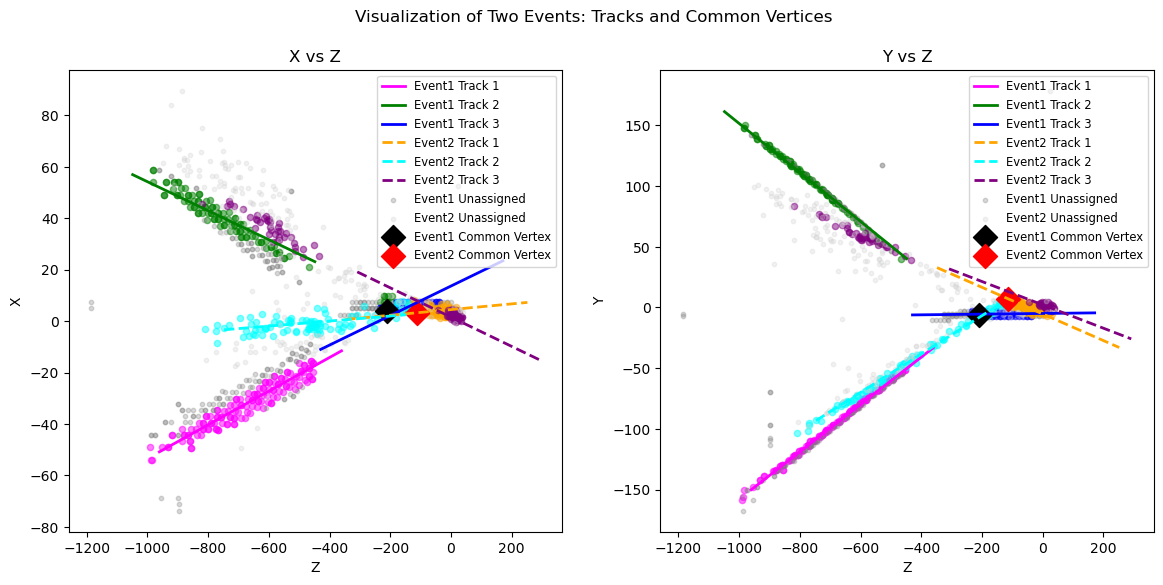

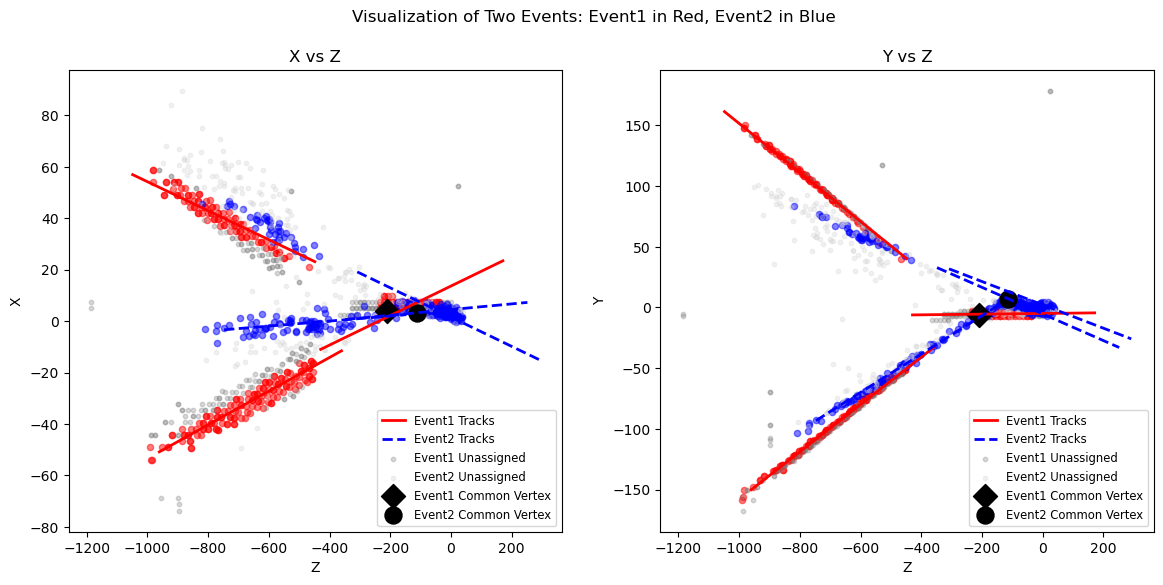

In [15]:
# =========================
# EVENT LOOP: VISUALIZE TWO EVENTS TOGETHER
# =========================

for i, batch in enumerate(exp_loader):
    if i == 1:
        data = batch[0].to(device)
        mu_sim, sigma_sim = model_sim.encoder(data)
        context_sim = reparameterize_gaussian(mean=mu_sim, logvar=sigma_sim)

        mu_exp, sigma_exp = model_exp.encoder(data)
        context_exp = reparameterize_gaussian(mean=mu_exp, logvar=sigma_exp)

        x_T, eps = dpm_encoder(data, model_exp, context_exp)
        x_T = x_T.to(device)
        eps = eps.to(device)
        print("Successfully encoded")
        x = sample(model_sim, 512, context_sim, x_T, eps)
        
        # For each event in the batch, process both original and translated versions.
        for j in range(len(x)):
            # Process original event.
            event_np = data[j].cpu().numpy()
            scaled_event_np = event_np
            scaled_event_np[:,0] *= 250
            scaled_event_np[:,1] *= 250
            scaled_event_np[:,2] = 500 * (scaled_event_np[:,2] - 1)
            tracks1, remaining1 = find_tracks(scaled_event_np, n_tracks=3, residual_threshold=5)
            if len(tracks1) < 2:
                print("Not enough tracks found in event 1 to compute a vertex.")
                continue
            t1_a, t1_b = pick_two_lowest_tracks_by_median_z(tracks1)
            vertex1 = compute_nearest_vertex(t1_a, t1_b)
            
            # Process translated event.
            translated_event_np = x[j].cpu().numpy()
            scaled_translated_event_np = translated_event_np
            scaled_translated_event_np[:,0] *= 250
            scaled_translated_event_np[:,1] *= 250
            scaled_translated_event_np[:,2] = 500 * (scaled_translated_event_np[:,2] - 1)
            tracks2, remaining2 = find_tracks(scaled_translated_event_np, n_tracks=3, residual_threshold=5)
            if len(tracks2) < 2:
                print("Not enough tracks found in event 2 to compute a vertex.")
                continue
            t2_a, t2_b = pick_two_lowest_tracks_by_median_z(tracks2)
            vertex2 = compute_nearest_vertex(t2_a, t2_b)
            
            # Visualize both events together.
            visualize_two_events_tracks_2d(tracks1, vertex1, remaining1,
                                             tracks2, vertex2, remaining2, z_range=300)
            visualize_two_events_tracks_2d_samecolor(tracks1, vertex1, remaining1,
                                             tracks2, vertex2, remaining2, z_range=300)